In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# arrays of data
theta_x = np.array([0, 0.25, 0, -0.05, -0.1, -0.25, -0.5, -0.75, -1], dtype=float) # degrees
freq_x = np.array([0.156, 0.199, 0.159, 0.152, 0.134, 0.113, 0.089, 0.093, 0.148], dtype=float) # Hz

theta_y = np.array([0.5, 0.75, 1, 1.25, 0, -0.25, -0.5, 0.25], dtype=float) # degrees
freq_y = np.array([0.201, 0.201, 0.210, 0.219, 0.175, 0.180, 0.203, 0.195], dtype=float) # Hz

In [3]:
# average multiple 0 degree x,y measurements
zero_mask_x = np.isclose(theta_x, 0.0)
avg0_x = freq_x[zero_mask_x].mean() if np.any(zero_mask_x) else None
tx = np.concatenate([theta_x[~zero_mask_x], [0.0]]) if avg0_x is not None else theta_x.copy()
fx = np.concatenate([freq_x[~zero_mask_x],  [avg0_x]]) if avg0_x is not None else freq_x.copy()
order = np.argsort(tx); tx, fx = tx[order], fx[order]

zero_mask_y = np.isclose(theta_y, 0.0)
avg0_y = freq_y[zero_mask_y].mean() if np.any(zero_mask_y) else None
ty = np.concatenate([theta_y[~zero_mask_y], [0.0]]) if avg0_y is not None else theta_y.copy()
fy = np.concatenate([freq_y[~zero_mask_y],  [avg0_y]]) if avg0_y is not None else freq_y.copy()
order = np.argsort(ty); ty, fy = ty[order], fy[order]


In [4]:
# quadratic fits 
ax, bx, cx = np.polyfit(tx, fx, 2)
ay, by, cy = np.polyfit(ty, fy, 2)

In [5]:
# vertex minimum
theta0_x = -bx/(2*ax); fmin_x = ax*theta0_x**2 + bx*theta0_x + cx
theta0_y = -by/(2*ay); fmin_y = ay*theta0_y**2 + by*theta0_y + cy

In [6]:
print("X-axis minimum: θ0_x = %.5f deg, f_min_x = %.5f Hz" % (theta0_x, fmin_x))
print("Y-axis minimum: θ0_y = %.5f deg, f_min_y = %.5f Hz" % (theta0_y, fmin_y))

X-axis minimum: θ0_x = -0.53152 deg, f_min_x = 0.09723 Hz
Y-axis minimum: θ0_y = 0.00847 deg, f_min_y = 0.18761 Hz


In [7]:
tx_curve = np.linspace(tx.min() - 0.1*np.ptp(tx), tx.max() + 0.1*np.ptp(tx), 400)
fx_curve = ax*tx_curve**2 + bx*tx_curve + cx

ty_curve = np.linspace(ty.min() - 0.1*np.ptp(ty), ty.max() + 0.1*np.ptp(ty), 400)
fy_curve = ay*ty_curve**2 + by*ty_curve + cy

Plot saved to: /Users/mollywatts/Downloads/first_mode_freq_vs_x_tilt.png


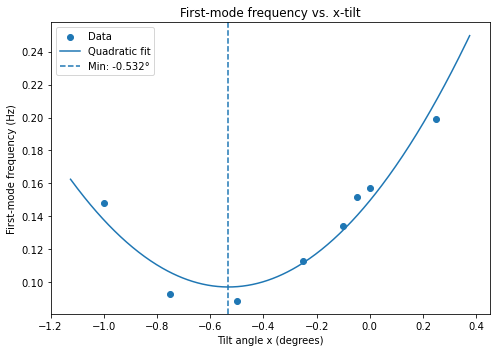

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(tx, fx, label='Data')
plt.plot(tx_curve, fx_curve, label='Quadratic fit')
plt.axvline(theta0_x, linestyle='--', label=f'Min: {theta0_x:.3f}°')
plt.title('First-mode frequency vs. x-tilt')
plt.xlabel('Tilt angle x (degrees)')
plt.ylabel('First-mode frequency (Hz)')
plt.legend()
plt.tight_layout()

save_path = '/Users/mollywatts/Downloads/first_mode_freq_vs_x_tilt.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot saved to: {save_path}")

plt.show()

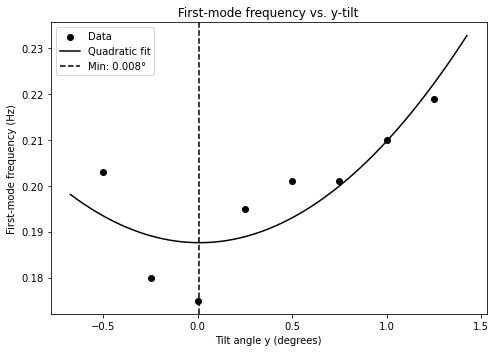

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(ty, fy, label='Data', color='k')
plt.plot(ty_curve, fy_curve, label='Quadratic fit', color='k')
plt.axvline(theta0_y, linestyle='--', label=f'Min: {theta0_y:.3f}°', color='k')
plt.title('First-mode frequency vs. y-tilt')
plt.xlabel('Tilt angle y (degrees)')
plt.ylabel('First-mode frequency (Hz)')
plt.legend()
plt.tight_layout()
plt.show()